## Testing Triskel-MC model selection with a small Gaussian problem 

	•	simulate data = white Gaussian noise + a random mixture of signals
	•	signals:
	•	Gaussian bumps: count ∈ {0,1,2} uniformly
	•	Tukey-window pulses: count ∈ {0,1} uniformly
	•	noise σ (“noise_sig”) ~ Uniform([1, Nsig_max])
	•	likelihood: d - \sum_j s_j(\theta_j) \sim \mathcal{N}(0,\sigma^2 I)

In [1]:

import matplotlib.pyplot  as plt
import numpy as np
from numpy.typing import ArrayLike

import pandas as pd
from dataclasses import dataclass

import jax
import jax.numpy as jnp
from jax import vmap, jit

from functools import partial


import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)

%load_ext autoreload
%autoreload 2




import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

# plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)




%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:


def rng_from_seed(seed=0):
    return np.random.default_rng(seed)

def log_uniform(a, b, x):
    # log Uniform([a,b]) density for scalar/array x (returns -inf outside)
    x = np.asarray(x)
    out = np.full_like(x, -np.inf, dtype=float)
    m = (x >= a) & (x <= b)
    out[m] = -np.log(b - a)
    return out

In [3]:
def gaussian_signal(x, A, sigma, x0):
    return A * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

# def tukey_window_1d(N, alpha):
#     """
#     Standard Tukey window of length N with taper fraction alpha in [0,1].
#     Returns w[n] for n=0..N-1.
#     """
#     if N <= 1:
#         return np.ones((N,), dtype=float)
#     alpha = float(alpha)
#     alpha = np.clip(alpha, 0.0, 1.0)
#     if alpha == 0.0:
#         return np.ones((N,), dtype=float)
#     if alpha == 1.0:
#         # Hann
#         n = np.arange(N)
#         return 0.5 * (1 - np.cos(2*np.pi*n/(N-1)))

#     n = np.arange(N)
#     w = np.ones((N,), dtype=float)
#     edge = int(np.floor(alpha*(N-1)/2.0))

#     # rising edge
#     if edge > 0:
#         n0 = np.arange(edge)
#         w[n0] = 0.5 * (1 + np.cos(np.pi*( (2*n0)/(alpha*(N-1)) - 1 )))
#         # falling edge
#         n1 = np.arange(N-edge, N)
#         k = n1 - (N-edge)
#         w[n1] = 0.5 * (1 + np.cos(np.pi*( (2*(N-1-n1))/(alpha*(N-1)) - 1 )))
#     return w

# def tukey_pulse(x, A, width, alpha, x0):
#     """
#     Tukey-window 'pulse' centered near x0 with total support ~width.
#     Implemented by placing a Tukey window on the nearest integer support.
#     """
#     width = float(width)
#     if width <= 0:
#         return np.zeros_like(x, dtype=float)

#     # integer support indices
#     half = 0.5 * width
#     i0 = int(np.floor(x0 - half))
#     i1 = int(np.ceil (x0 + half))
#     i0 = max(i0, 0)
#     i1 = min(i1, int(x[-1]) if np.all(np.isclose(np.diff(x), 1.0)) else len(x)-1)
#     # convert to index range in x-array (assume x = 0..L-1 integer grid)
#     i0 = max(i0, 0)
#     i1 = min(i1, len(x)-1)

#     N = i1 - i0 + 1
#     if N <= 0:
#         return np.zeros_like(x, dtype=float)

#     w = tukey_window_1d(N, alpha)
#     y = np.zeros_like(x, dtype=float)
#     y[i0:i1+1] = A * w
#     return y

### vectorisable RTukey signal


def tukey_pulse_vec(x, A, width, alpha, x0):
    """
    Vectorizable Tukey-like pulse.
    x: (L,)
    A,width,alpha,x0 can be scalars or arrays broadcastable to (B,1)
    returns (B,L) if A is (B,1), else (L,)
    """
    x = np.asarray(x, dtype=float)
    A = np.asarray(A, dtype=float)
    width = np.asarray(width, dtype=float)
    alpha = np.clip(np.asarray(alpha, dtype=float), 0.0, 1.0)
    x0 = np.asarray(x0, dtype=float)

    half = 0.5 * np.maximum(width, 1e-12)
    u = np.abs(x - x0) / half  # broadcast

    # support mask
    inside = (u < 1.0)

    # flat region threshold
    # when alpha=0 -> flat region is whole support; when alpha=1 -> no flat region (pure Hann-like)
    flat_thr = np.clip(1.0 - alpha, 0.0, 1.0)

    flat = inside & (u <= flat_thr)

    # taper: u in (flat_thr, 1)
    taper = inside & (~flat)

    y = np.zeros_like(u, dtype=float)

    # flat part = 1
    y = np.where(flat, 1.0, y)

    # taper part: cosine from 1 at u=flat_thr to 0 at u=1
    # t = (u - flat_thr)/(1-flat_thr) in (0,1)
    denom = np.maximum(1.0 - flat_thr, 1e-12)
    t = (u - flat_thr) / denom
    y = np.where(taper, 0.5 * (1.0 + np.cos(np.pi * t)), y)

    return A * y

In [4]:
@dataclass
class SimConfig:
    L: int = 512
    # noise sigma prior
    Nsig_max: float = 5.0

    # gaussian signal priors
    sig_min: float = 2.0
    sig_max: float = 10.0
    x_min: float = 50.0
    x_max: float = 500.0  # should be < L
    A_scale: float = 5.0  # amplitude prior is Uniform([0, A_scale*Nsig_max])

    # tukey priors
    w_min: float = 10.0
    w_max: float = 100.0
    alpha_min: float = 0.05
    alpha_max: float = 0.95



### Make a dataset



	•	noise_sig ~ U(1, Nsig_max)
	•	n_gauss ∈ {0,1,2} uniform
	•	n_tukey ∈ {0,1} uniform

In [5]:
def sample_ground_truth(rng, cfg: SimConfig):
    L = cfg.L
    x = np.arange(L, dtype=float)

    noise_sig = rng.uniform(1.0, cfg.Nsig_max)

    # counts
    n_gauss = int(rng.integers(0, 3))  # 0,1,2
    n_tukey = int(rng.integers(0, 2))  # 0,1

    gauss_params = []
    for _ in range(n_gauss):
        A = rng.uniform(0.0, cfg.A_scale * cfg.Nsig_max)
        sig = rng.uniform(cfg.sig_min, cfg.sig_max)
        x0 = rng.uniform(cfg.x_min, min(cfg.x_max, L - 1.0))
        gauss_params.append((A, sig, x0))

    tukey_params = []
    for _ in range(n_tukey):
        A = rng.uniform(0.0, cfg.A_scale * cfg.Nsig_max)
        w = rng.uniform(cfg.w_min, cfg.w_max)
        alpha = rng.uniform(cfg.alpha_min, cfg.alpha_max)
        x0 = rng.uniform(cfg.x_min, min(cfg.x_max, L - 1.0))
        tukey_params.append((A, w, alpha, x0))

    # build signal
    s = np.zeros(L, dtype=float)
    for (A, sig, x0) in gauss_params:
        s += gaussian_signal(x, A, sig, x0)

    # <<< CHANGED: use tukey_pulse_vec >>>
    for (A, w, alpha, x0) in tukey_params:
        s += tukey_pulse_vec(x, A, w, alpha, x0)

    # noise + data
    n = rng.normal(0.0, noise_sig, size=L)
    d = s + n

    truth = {
        "noise_sig": noise_sig,
        "gauss_params": gauss_params,
        "tukey_params": tukey_params,
        "signal": s,
        "noise": n,
        "data": d,
    }
    return x, truth

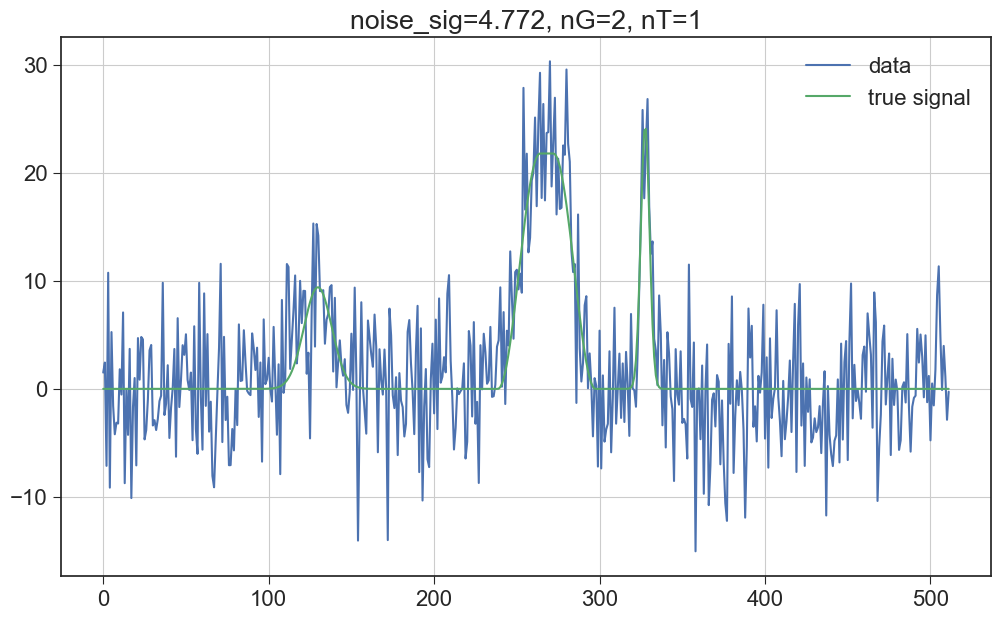

Gaussian ['A', 'sig', 'x0'] 
 [(24.406092642692602, 2.6466881911648175, 327.5616152217285), (9.412164609431814, 8.415209655886457, 129.759211977821)]
Tukey ['A', 'w', 'alpha', 'x0'] 
 [(21.79088185469141, 58.954726068714834, 0.8619935717443894, 268.0591603945173)]


In [6]:
cfg = SimConfig(L=512, Nsig_max=5.0, x_max=507.0)
rng = rng_from_seed(4)

x, truth = sample_ground_truth(rng, cfg)

plt.figure()
plt.plot(x, truth["data"], label="data")
plt.plot(x, truth["signal"], label="true signal")
plt.legend()
plt.title(f"noise_sig={truth['noise_sig']:.3f}, nG={len(truth['gauss_params'])}, nT={len(truth['tukey_params'])}")
plt.show()

Gaussian_params = ["A", "sig", "x0"]
Tukey_params = ["A", "w", "alpha", "x0"]

print ("Gaussian", Gaussian_params, "\n", truth["gauss_params"])
print ("Tukey", Tukey_params, "\n", truth["tukey_params"])

### Likelihood and log posterior pieces (Point 2)



We’ll represent a candidate model by:

	•	noise_sig (always present)
	•	gauss_params: list of up to 2 Gaussian components (active ones)
	•	tukey_params: list of up to 1 Tukey component (active ones)

In [13]:
def synthesize_signal(x, gauss_params, tukey_params):
    s = np.zeros_like(x, dtype=float)
    for (A, sig, x0) in gauss_params:
        s += gaussian_signal(x, A, sig, x0)
    for (A, w, alpha, x0) in tukey_params:
        s += tukey_pulse_vec(x, A, w, alpha, x0)
    return s

def loglik_gaussian_iid(d, s, noise_sig):
    """
    d = s + n, n ~ N(0, noise_sig^2 I)
    """
    noise_sig = float(noise_sig)
    if noise_sig <= 0 or not np.isfinite(noise_sig):
        return -np.inf
    r = d - s
    L = r.size
    return -0.5 * (np.sum(r*r) / (noise_sig**2) + L*np.log(2*np.pi*noise_sig**2))

In [14]:
def logprior_noise(noise_sig, cfg: SimConfig):
    return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

def logprior_gauss_component(A, sig, x0, cfg: SimConfig):
    lp = 0.0
    lp += float(log_uniform(0.0, cfg.A_scale*cfg.Nsig_max, A))
    lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
    lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L-1.0), x0))
    return lp

def logprior_tukey_component(A, w, alpha, x0, cfg: SimConfig):
    lp = 0.0
    lp += float(log_uniform(0.0, cfg.A_scale*cfg.Nsig_max, A))
    lp += float(log_uniform(cfg.w_min, cfg.w_max, w))
    lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
    lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L-1.0), x0))
    return lp

def logprior_model(noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    lp = logprior_noise(noise_sig, cfg)
    for (A, sig, x0) in gauss_params:
        lp += logprior_gauss_component(A, sig, x0, cfg)
    for (A, w, alpha, x0) in tukey_params:
        lp += logprior_tukey_component(A, w, alpha, x0, cfg)
    return float(lp)

In [15]:
print ("noise prior", logprior_noise(truth["noise_sig"], cfg))
for i, (A, sig, x0) in enumerate(truth["gauss_params"]):
    print (f"Gaussian {i} prior", logprior_gauss_component(A, sig, x0, cfg))
for i, (A, w, alpha, x0) in enumerate(truth["tukey_params"]):
    print (f"Tukey {i} prior", logprior_tukey_component(A, w, alpha, x0, cfg))

noise prior -1.3862943611198906
Gaussian 0 prior -11.423000757442242
Gaussian 1 prior -11.423000757442242
Tukey 0 prior -13.738008370434844


In [16]:
def logposterior(d, x, noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    s = synthesize_signal(x, gauss_params, tukey_params)
    ll = loglik_gaussian_iid(d, s, noise_sig)
    if not np.isfinite(ll):
        return -np.inf
    lp = logprior_model(noise_sig, gauss_params, tukey_params, cfg)
    return lp + ll

In [17]:
# print ("log posteriror", logposterior(truth["data"], x, truth["noise_sig"], truth["gauss_params"], truth["tukey_params"], cfg))

d = truth["data"]

lp_true = logposterior(
    d, x,
    truth["noise_sig"],
    truth["gauss_params"],
    truth["tukey_params"],
    cfg
)

lp_noise_only = logposterior(
    d, x,
    truth["noise_sig"],
    [], [],  # no signals
    cfg
)

print ("log posterior (true model)", lp_true)
print ("log posterior (noise only)", lp_noise_only) 

log posterior (true model) -1566.2008375621438
log posterior (noise only) -1944.317715703319


### Making necessary functions

In [18]:
SLOT_DIM  = np.array([1,3,3,4], dtype=np.int32)
KMAX, DMAX = 4, 4

In [19]:
def pack_state_from_components(noise_sig, gauss_params, tukey_params):
    phi = np.zeros((KMAX, DMAX), dtype=np.float64)
    m   = np.zeros((KMAX,), dtype=bool)

    # noise always present
    phi[0,0] = noise_sig
    m[0] = True

    # up to two gaussians -> slots 1,2
    for j, (A,sig,x0) in enumerate(gauss_params[:2], start=1):
        phi[j,0:3] = (A, sig, x0)
        m[j] = True

    # at most one tukey -> slot 3
    if len(tukey_params) > 0:
        A,w,a,x0 = tukey_params[0]
        phi[3,0:4] = (A,w,a,x0)
        m[3] = True

    return phi, m

def init_product_space_state(rng, C, W, cfg: SimConfig):
    phi = np.zeros((C,W,KMAX,DMAX), dtype=np.float64)
    m   = np.zeros((C,W,KMAX), dtype=bool)

    # noise always on
    phi[:,:,0,0] = rng.uniform(1.0, cfg.Nsig_max, size=(C,W))
    m[:,:,0] = True

    # start with no signals (can change later)
    return phi, m

In [ ]:
def log_lik_masked_np(
    phi: np.ndarray,          # (Kmax, dmax) padded
    m: np.ndarray,            # (Kmax,) bool
    rest: Optional[np.ndarray],
    *,
    d: np.ndarray,            # observed data (L,)
    x: np.ndarray,            # grid (L,)
    slot_dim: np.ndarray,     # (Kmax,)
    slot_type: np.ndarray,    # (Kmax,)
) -> float:
    """
    Returns scalar log-likelihood for one state.
    """
    phi = np.asarray(phi, dtype=float)
    m = np.asarray(m, dtype=bool)

    # build signal from active components
    s = np.zeros_like(x, dtype=float)

    # noise must be on (in your design); still read it from active slots:
    noise_sig = None

    for j in range(m.shape[0]):
        if not m[j]:
            continue
        dj = int(slot_dim[j])
        tj = int(slot_type[j])
        v = phi[j, :dj]

        if tj == TYPE_NOISE:
            noise_sig = float(v[0])

        elif tj == TYPE_GAUSS:
            A, sig, x0 = map(float, v[:3])
            s += gaussian_signal(x, A, sig, x0)

        elif tj == TYPE_TUKEY:
            A, width, alpha, x0 = map(float, v[:4])
            # vectorizable version, but here single component => returns (L,)
            s += tukey_pulse_vec(x, A, width, alpha, x0)

        else:
            return -np.inf

    if noise_sig is None:
        return -np.inf

    return float(loglik_gaussian_iid(d, s, noise_sig))

batched_ll_masked = make_batched_loglik_masked_numpy(
    lambda phi1, m1, rest1: log_lik_masked_np(
        phi1, m1, rest1,
        d=obs_d,
        x=grid_x,
        slot_dim=slot_dim,
        slot_type=slot_type,
    )
)

In [ ]:
def gaussian_signal_vec(x, A, sigma, x0):
    # x: (L,), A/sigma/x0 broadcastable to (B,1) → output (B,L)
    x = np.asarray(x, dtype=float)
    A = np.asarray(A, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    x0 = np.asarray(x0, dtype=float)
    return A * np.exp(-0.5 * ((x - x0) / np.maximum(sigma, 1e-12)) ** 2)





# def synthesize_signal_masked_batch_numpy(x, phi_b, m_b):
#     """
#     x:     (L,)
#     phi_b: (B,Kmax,dmax) padded
#     m_b:   (B,Kmax) bool
#     returns s_b: (B,L)
#     """
#     x = np.asarray(x, dtype=float)
#     phi_b = np.asarray(phi_b, dtype=float)
#     m_b = np.asarray(m_b, dtype=bool)

#     B, Kmax, dmax = phi_b.shape
#     L = x.size
#     s = np.zeros((B, L), dtype=float)

#     # --- Gaussian slots: 1 and 2 ---
#     for j in (1, 2):
#         active = m_b[:, j]  # (B,)
#         if not np.any(active):
#             continue
#         A   = phi_b[:, j, 0][:, None]  # (B,1)
#         sig = phi_b[:, j, 1][:, None]
#         x0  = phi_b[:, j, 2][:, None]
#         gj = gaussian_signal_vec(x[None, :], A, sig, x0)  # (B,L)
#         s += gj * active[:, None]

#     # --- Tukey slot: 3 ---
#     j = 3
#     active = m_b[:, j]
#     if np.any(active):
#         A     = phi_b[:, j, 0][:, None]
#         width = phi_b[:, j, 1][:, None]
#         alpha = phi_b[:, j, 2][:, None]
#         x0    = phi_b[:, j, 3][:, None]
#         tj = tukey_pulse_vec(x[None, :], A, width, alpha, x0)  # (B,L)
#         s += tj * active[:, None]

#     return s



In [22]:
def loglik_masked_numpy_factory(d, x):
    """
    Returns a function log_lik_masked_np(phi, m, rest) -> float
    compatible with Triskel-MC's make_batched_loglik_masked wrapper.
    """
    d = np.asarray(d, dtype=float)
    x = np.asarray(x, dtype=float)
    L = d.size
    const = -0.5 * L * np.log(2.0 * np.pi)

    def log_lik_masked_np(phi, m, rest=None):
        """
        phi: (Kmax,dmax) padded
        m:   (Kmax,) bool
        rest: unused (keep signature)
        returns scalar log-likelihood
        """
        phi = np.asarray(phi, dtype=float)
        m = np.asarray(m, dtype=bool)

        # noise sigma from slot 0
        noise_sig = float(phi[0, 0])
        if (noise_sig <= 0.0) or (not np.isfinite(noise_sig)):
            return -np.inf

        # build model signal from active slots
        s = synthesize_signal_masked_batch_numpy(x, phi[None, ...], m[None, ...])[0]  # (L,)

        r = d - s
        inv_var = 1.0 / (noise_sig * noise_sig)
        ll = const - L * np.log(noise_sig) - 0.5 * inv_var * float(np.dot(r, r))
        return float(ll)

    return log_lik_masked_np

In [24]:

from typing import Callable, Optional

def make_batched_loglik_masked_numpy(
    log_lik_masked_np: Callable[[np.ndarray, np.ndarray, Optional[np.ndarray]], float],
):
    """
    Pure NumPy drop-in replacement for make_batched_loglik_masked.

    Takes a *single-sample* masked log-likelihood:
        log_lik_masked_np(phi, m, rest) -> scalar

    Returns a *batched* evaluator:
        batched(phi_b, m_b, rest_b) -> (B,) float64

    Shapes:
      phi_b:  (B, Kmax, dmax)
      m_b:    (B, Kmax) bool
      rest_b: (B, Drest) or None

    Notes:
    - This is a straightforward Python loop over batch items (NumPy-first, no JAX).
    - If you want a truly vectorized (no Python loop) batched LL, we can build that too,
      but this is the safest "drop-in" for Triskel-MC right now.
    """
    def batched(phi_b: np.ndarray, m_b: np.ndarray, rest_b: Optional[np.ndarray]) -> np.ndarray:
        phi_b = np.asarray(phi_b)
        m_b = np.asarray(m_b, dtype=bool)
        if phi_b.ndim != 3:
            raise ValueError(f"phi_b must have shape (B,Kmax,dmax), got {phi_b.shape}")
        if m_b.ndim != 2:
            raise ValueError(f"m_b must have shape (B,Kmax), got {m_b.shape}")
        if phi_b.shape[0] != m_b.shape[0] or phi_b.shape[1] != m_b.shape[1]:
            raise ValueError(f"phi_b and m_b batch/Kmax mismatch: {phi_b.shape} vs {m_b.shape}")

        B = phi_b.shape[0]
        out = np.empty((B,), dtype=np.float64)

        if rest_b is None:
            for b in range(B):
                out[b] = float(log_lik_masked_np(phi_b[b], m_b[b], None))
        else:
            rest_b = np.asarray(rest_b)
            if rest_b.shape[0] != B:
                raise ValueError(f"rest_b must have batch dim B={B}, got {rest_b.shape}")
            for b in range(B):
                out[b] = float(log_lik_masked_np(phi_b[b], m_b[b], rest_b[b]))

        return out

    return batched

In [26]:

from typing import Optional

# Example type ids (you can choose any ints)
TYPE_NOISE = 0
TYPE_GAUSS = 1
TYPE_TUKEY = 2

def log_prior_phi_np(phi_j: np.ndarray, type_j: int, cfg) -> float:
    """
    Prior for ACTIVE slot parameters.
    phi_j: shape (dj,) (already sliced to slot_dim[j])
    type_j: int label for that slot
    """
    phi_j = np.asarray(phi_j, dtype=float)
    t = int(type_j)

    if t == TYPE_NOISE:
        noise_sig = float(phi_j[0])
        return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

    elif t == TYPE_GAUSS:
        A   = float(phi_j[0])
        sig = float(phi_j[1])
        x0  = float(phi_j[2])
        lp = 0.0
        lp += float(log_uniform(0.0, cfg.A_scale * cfg.Nsig_max, A))
        lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
        lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
        return float(lp)

    elif t == TYPE_TUKEY:
        A     = float(phi_j[0])
        width = float(phi_j[1])
        alpha = float(phi_j[2])
        x0    = float(phi_j[3])
        lp = 0.0
        lp += float(log_uniform(0.0, cfg.A_scale * cfg.Nsig_max, A))
        lp += float(log_uniform(cfg.w_min, cfg.w_max, width))
        lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
        lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L - 1.0), x0))
        return float(lp)

    else:
        # unknown type => forbid
        return -np.inf


def log_pseudo_phi_np(phi_j: np.ndarray, type_j: int, cfg) -> float:
    """
    Pseudo-prior for INACTIVE slot parameters.
    For the toy problem, simplest is: use the SAME distribution as the prior.
    (That makes births/deaths easier to debug and still valid.)
    """
    return log_prior_phi_np(phi_j, type_j, cfg)

In [27]:
def log_p_mask_np(
    m: np.ndarray,                    # (C,W,Kmax) bool
    slot_type: np.ndarray,            # (Kmax,) int labels (not necessarily used here)
    must_be_on: Optional[np.ndarray], # (Kmax,) bool or None
    can_toggle: Optional[np.ndarray], # (Kmax,) bool or None
) -> np.ndarray:
    """
    Returns log p(m) for each (C,W). Shape (C,W).

    This version is:
      - hard constraints only (invalid masks -> -inf)
      - otherwise uniform over masks (0.0)
    """
    m = np.asarray(m, dtype=bool)
    C, W, Kmax = m.shape

    lp = np.zeros((C, W), dtype=np.float64)

    # must_be_on: enforce those slots are True
    if must_be_on is not None:
        must_be_on = np.asarray(must_be_on, dtype=bool)
        if must_be_on.shape != (Kmax,):
            raise ValueError(f"must_be_on must have shape (Kmax,), got {must_be_on.shape}")
        ok = np.all(m[..., must_be_on], axis=-1)  # (C,W)
        lp = np.where(ok, lp, -np.inf)

    # can_toggle: if False, the slot must never change from its initial convention.
    # For a generic mask prior, the safest is: if can_toggle[j]==False then slot is REQUIRED ON.
    # (If you need "fixed OFF", add another array e.g. must_be_off.)
    if can_toggle is not None:
        can_toggle = np.asarray(can_toggle, dtype=bool)
        if can_toggle.shape != (Kmax,):
            raise ValueError(f"can_toggle must have shape (Kmax,), got {can_toggle.shape}")
        fixed = ~can_toggle
        if np.any(fixed):
            ok = np.all(m[..., fixed], axis=-1)  # require fixed slots ON
            lp = np.where(ok, lp, -np.inf)

    return lp

In [ ]:
# Later:
# Kmax = 4
# slot_dim  = [1, 3, 3, 4]
# slot_type = (user-defined labels like ["noise","gauss","gauss","tukey"] or ints)
# must_be_on = [True, False, False, False]
# can_toggle = [False, True, True, True]  # noise not toggled

print("Sampler integration will come next once we update Triskel-MC for typed slots + constraints.")